In [7]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score,make_scorer


## 1. Business Understanding

In [8]:
credit_card_usage_data = pd.read_csv("credit_card_clean.csv")
credit_card_usage_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


1. Basically this data is about customer credit card bill payment history
2. It has Pay1, Pay2, Pay3 etc month wise
3. So, based on the historical data whether customer will pay in the next/upcoming month
4. If business has certain predication in advance,it will help them to decide how to make customer pay the bill on time
5. The output prediction should yes or no whether the customer pay or not, so it is a discrete data, so we have to use classifier algorithm

#### Conclusion
    We understand the business, let's go for the model building
    

## 2. Data Understanding
#### As part of business understanding we already understand the observations and feature

In [115]:
credit_card_usage_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [35]:
credit_card_usage_data.shape

(30000, 25)

In [37]:
credit_card_usage_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 3. Data Preparation

#### Analye and apply the common sense that remove unnecessary column which does not really helpful for prediction

In [9]:
del credit_card_usage_data["ID"]

#### Convert object into numbers ans ML expect only numerical data

In [10]:
#Using label encoder we can convert this column into numerical Sex, Educational, Marriage
le = LabelEncoder()
credit_card_usage_data["SEX"] = le.fit_transform(credit_card_usage_data["SEX"])
credit_card_usage_data["EDUCATION"] = le.fit_transform(credit_card_usage_data["EDUCATION"])
credit_card_usage_data["MARRIAGE"] = le.fit_transform(credit_card_usage_data["MARRIAGE"])

In [11]:
credit_card_usage_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,0,3,0,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,0,3,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,0,3,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,0,3,0,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,3,0,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,1,0,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,1,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,3,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,1,0,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 4. Model Building

In [12]:
X = credit_card_usage_data.drop("DEFAULT",axis=1)
y = credit_card_usage_data["DEFAULT"]

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=123,shuffle=True,stratify=y) 
#Stratify can only be used for discrete data

xgb_classifier  = XGBClassifier(n_estimators = 200,gamma=2,reg_alpha=0.5,learning_rate=0.1)
lgbm_classifier = LGBMClassifier(n_estimators = 200)



## 5. Mode Training

In [14]:
%%time
xgb_classifier.fit(X_train,y_train)

CPU times: total: 3.16 s
Wall time: 778 ms


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [15]:
%%time
lgbm_classifier.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3259
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 7.97 s
Wall time: 3.43 s


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 6. Model Testing

In [ ]:

y_pred_xgb = xgb_classifier.predict(X_train)
y_pred_lgb = lgbm_classifier.predict(X_train)


y_pred_test_xgb = xgb_classifier.predict(X_test)
y_pred_test_lgb = lgbm_classifier.predict(X_test)

## 7. Model Evaulation

In [ ]:
print("Accuracy Score : ",round(accuracy_score(y_train,y_pred_xgb),2))
print("Precision Score:",round(precision_score(y_train,y_pred_xgb),2))
print("Recall Score",recall_score(y_train,y_pred_xgb))
print("Confusion Matrix\n",confusion_matrix(y_train,y_pred_xgb))

In [ ]:
print("Accuracy Score : ",round(accuracy_score(y_train,y_pred_lgb),2))
print("Precision Score:",round(precision_score(y_train,y_pred_lgb),2))
print("Recall Score",recall_score(y_train,y_pred_lgb))
print("Confusion Matrix\n",confusion_matrix(y_train,y_pred_lgb))

## Let's Learn Feature Importance

-each algorithm will take different features at each iteration.

-Suppose, if we get the top 10 features, then using this itself we can build the model, also it helps to reduce the complexity and increase the accuracy

- After model building, even we can take the top 10 features, that mean which feature frequently has taken for decision tree growth

In [17]:
xgb_feature_imp = xgb_classifier.feature_importances_
lgb_feature_imp = lgbm_classifier.feature_importances_

In [20]:
feature_importance_list = pd.DataFrame(data = {"Features":X.columns,
                                              "XGB_Features":xgb_feature_imp,
                                              "LGB_Features":lgb_feature_imp})
feature_importance_list

,Features,XGB_Features,LGB_Features
0,LIMIT_BAL,0.020720,436
1,SEX,0.013315,82
2,EDUCATION,0.012903,132
3,MARRIAGE,0.013131,61
4,AGE,0.011468,462
5,PAY_1,0.504954,149
6,PAY_2,0.089726,74
7,PAY_3,0.042109,75
8,PAY_4,0.049142,57
9,PAY_5,0.031609,56


## Question :1 Display the top 10 Features of Adaboost

In [21]:
import seaborn as sns

In [23]:
xgbboost_top_features = feature_importance_list.sort_values(by = "XGB_Features",ascending = False)
top_10_xgb_features = xgbboost_top_features.head(10)
top_10_xgb_features

,Features,XGB_Features,LGB_Features
5,PAY_1,0.504954,149
6,PAY_2,0.089726,74
8,PAY_4,0.049142,57
7,PAY_3,0.042109,75
9,PAY_5,0.031609,56
19,PAY_AMT3,0.022202,380
18,PAY_AMT2,0.022165,416
10,PAY_6,0.021199,74
0,LIMIT_BAL,0.020720,436
11,BILL_AMT1,0.018969,435


<Axes: xlabel='XGB_Features', ylabel='Features'>

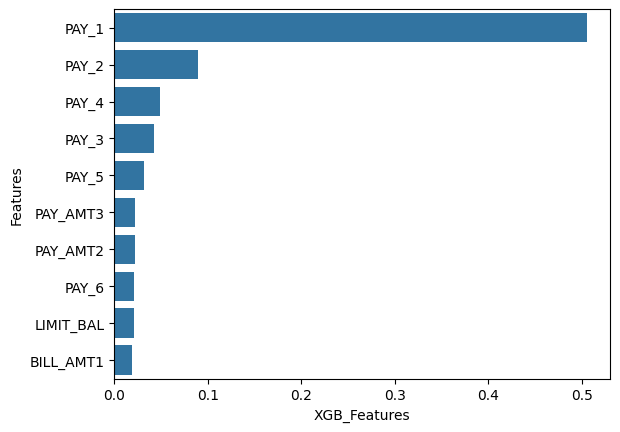

In [26]:
sns.barplot(data  = top_10_xgb_features,y="Features",x = "XGB_Features",)